# Imagery Multi-Split Improvement Study

This notebook focuses on improving imagery-only decoding in a statistically more defensible way.

Instead of trusting a single subject split, it repeats the strongest imagery-only candidates across multiple random group splits and aggregates the results.

Scope:

- models: `EEGNet`, `ShallowConvNet`
- evaluation: `5` random group splits
- ablations:
  - time window
  - frequency band
  - channel subset
- outputs:
  - mean and standard deviation of balanced accuracy
  - plots with uncertainty
  - final recommended configuration


In [1]:
import random
import time
import warnings
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import display
from braindecode.models import EEGNet, ShallowFBCSPNet
from mne import Epochs, pick_types
from mne.channels import make_standard_montage
from mne.datasets import eegbci
from mne.io import concatenate_raws, read_raw_edf
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import GroupShuffleSplit
from torch.utils.data import DataLoader, TensorDataset


warnings.filterwarnings("ignore", category=RuntimeWarning)
mne.set_log_level("ERROR")
plt.style.use("seaborn-v0_8-whitegrid")

SEED = 7
DATA_ROOT = Path("/NAS/aniruddham/mne/data")
RUNS = [4, 8, 12]
RESAMPLE_SFREQ = 160.0
EPOCH_WINDOW = (0.0, 4.0)
DEFAULT_CROP_WINDOW = (0.5, 2.5)
DEFAULT_FILTER_BAND = (8.0, 30.0)
WINDOW_OPTIONS = [(0.5, 2.5), (0.5, 4.0), (1.0, 3.0)]
BAND_OPTIONS = [(8.0, 30.0), (14.0, 30.0), (8.0, 14.0)]
CHANNEL_OPTIONS = {
    "all_channels": None,
    "sensorimotor_9": ["FC3", "FCz", "FC4", "C3", "Cz", "C4", "CP3", "CPz", "CP4"],
    "sensorimotor_17": [
        "FC5",
        "FC3",
        "FC1",
        "FCz",
        "FC2",
        "FC4",
        "FC6",
        "C5",
        "C3",
        "C1",
        "Cz",
        "C2",
        "C4",
        "C6",
        "CP3",
        "CPz",
        "CP4",
    ],
}
MODEL_NAMES = ["EEGNet", "ShallowConvNet"]
N_SPLITS = 5
MAX_SUBJECTS = None
BATCH_SIZE = 64
MAX_EPOCHS = 12
EARLY_STOPPING_PATIENCE = 3
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
TEST_SIZE = 0.2
VAL_SIZE = 0.2
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MONTAGE = make_standard_montage("standard_1005")

if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

print(f"Using device: {DEVICE}")


Using device: cuda


In [2]:
def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def infer_available_subjects(data_root: Path = DATA_ROOT) -> list[int]:
    return sorted(
        int(path.name[1:])
        for path in data_root.glob("S[0-9][0-9][0-9]")
        if path.is_dir()
    )


def local_run_paths(
    subject: int, runs: list[int], data_root: Path = DATA_ROOT
) -> list[Path]:
    subject_name = f"S{subject:03d}"
    return [data_root / subject_name / f"{subject_name}R{run:02d}.edf" for run in runs]


def load_subject_raw(subject: int, runs: list[int] = RUNS) -> mne.io.BaseRaw:
    paths = local_run_paths(subject, runs)
    raw = concatenate_raws(
        [read_raw_edf(path, preload=True, verbose="ERROR") for path in paths]
    )
    eegbci.standardize(raw)
    raw.pick("eeg")
    raw.set_montage(MONTAGE, match_case=False, on_missing="warn")
    raw.annotations.rename({"T1": "left_hand", "T2": "right_hand"})
    raw.set_eeg_reference("average", projection=False, verbose="ERROR")
    raw.resample(RESAMPLE_SFREQ, verbose="ERROR")
    return raw


def epoch_subject(
    raw: mne.io.BaseRaw, crop_window, filter_band
) -> tuple[np.ndarray, np.ndarray, Epochs]:
    raw = raw.copy()
    raw.filter(
        *filter_band, fir_design="firwin", skip_by_annotation="edge", verbose="ERROR"
    )
    events, event_map = mne.events_from_annotations(raw, verbose="ERROR")
    epochs = Epochs(
        raw,
        events,
        event_id={
            "left_hand": event_map["left_hand"],
            "right_hand": event_map["right_hand"],
        },
        tmin=EPOCH_WINDOW[0],
        tmax=EPOCH_WINDOW[1],
        proj=False,
        picks=pick_types(
            raw.info, meg=False, eeg=True, stim=False, eog=False, exclude="bads"
        ),
        baseline=None,
        preload=True,
        reject_by_annotation=True,
        verbose="ERROR",
    ).crop(*crop_window)
    if len(epochs.times) % 2 != 0:
        epochs.crop(tmin=epochs.tmin, tmax=epochs.times[-2])
    X = epochs.get_data(copy=False).astype(np.float32)
    y = (epochs.events[:, -1] == event_map["right_hand"]).astype(np.int64)
    return X, y, epochs


def select_channels(X, channel_names, chs_info, wanted):
    if wanted is None:
        return X, channel_names, chs_info
    name_to_idx = {name: idx for idx, name in enumerate(channel_names)}
    picks = [name_to_idx[ch] for ch in wanted if ch in name_to_idx]
    return (
        X[:, picks, :],
        [channel_names[idx] for idx in picks],
        [deepcopy(chs_info[idx]) for idx in picks],
    )


def build_dataset(
    crop_window=DEFAULT_CROP_WINDOW, filter_band=DEFAULT_FILTER_BAND
) -> dict:
    subjects = infer_available_subjects()
    if MAX_SUBJECTS is not None:
        subjects = subjects[:MAX_SUBJECTS]

    X_parts = []
    y_parts = []
    groups = []
    channel_names = None
    chs_info = None
    example_epochs = None

    for subject in subjects:
        raw = load_subject_raw(subject)
        X, y, epochs = epoch_subject(
            raw, crop_window=crop_window, filter_band=filter_band
        )
        mean = X.mean(axis=2, keepdims=True)
        std = X.std(axis=2, keepdims=True) + 1e-6
        X = (X - mean) / std

        if channel_names is None:
            channel_names = epochs.ch_names
            chs_info = deepcopy(epochs.info["chs"])
            example_epochs = epochs.copy()

        X_parts.append(X)
        y_parts.append(y)
        groups.append(np.full(len(y), subject))

    return {
        "X": np.concatenate(X_parts, axis=0),
        "y": np.concatenate(y_parts, axis=0),
        "groups": np.concatenate(groups, axis=0),
        "channel_names": list(channel_names),
        "chs_info": chs_info,
        "sfreq": RESAMPLE_SFREQ,
        "example_epochs": example_epochs,
        "crop_window": crop_window,
        "filter_band": filter_band,
    }


set_seed()
base_dataset = build_dataset()
dataset_summary = pd.DataFrame(
    {
        "metric": [
            "epochs_total",
            "left_trials",
            "right_trials",
            "channels",
            "samples_per_epoch",
            "splits",
        ],
        "value": [
            len(base_dataset["y"]),
            int((base_dataset["y"] == 0).sum()),
            int((base_dataset["y"] == 1).sum()),
            len(base_dataset["channel_names"]),
            base_dataset["X"].shape[-1],
            N_SPLITS,
        ],
    }
)
display(dataset_summary)


,metric,value
0,epochs_total,4898
1,left_trials,2470
2,right_trials,2428
3,channels,64
4,samples_per_epoch,320
5,splits,5


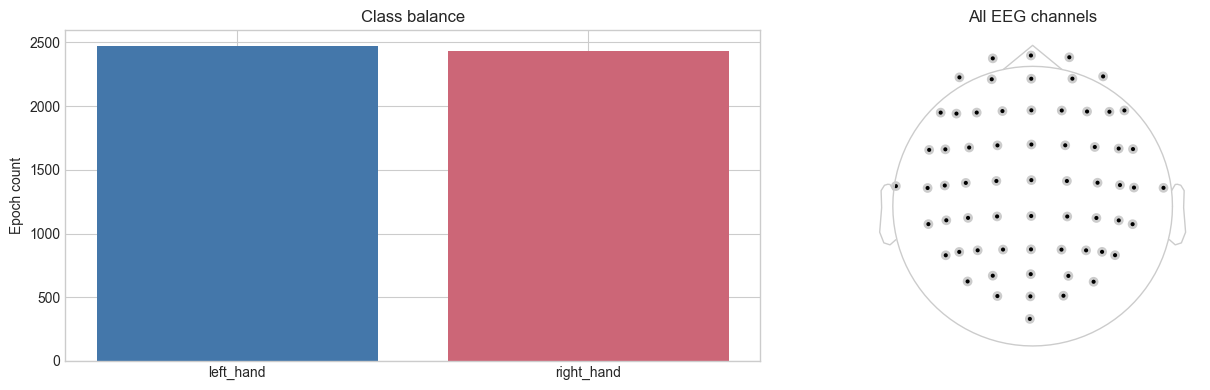

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
class_counts = (
    pd.Series(base_dataset["y"])
    .map({0: "left_hand", 1: "right_hand"})
    .value_counts()
    .sort_index()
)
axes[0].bar(class_counts.index, class_counts.values, color=["#4477AA", "#CC6677"])
axes[0].set_title("Class balance")
axes[0].set_ylabel("Epoch count")

mne.viz.plot_sensors(
    base_dataset["example_epochs"].info, axes=axes[1], show=False, kind="topomap"
)
axes[1].set_title("All EEG channels")
plt.tight_layout()
plt.show()


In [4]:
def make_group_split(groups: np.ndarray, seed: int) -> dict:
    index = np.arange(len(groups))
    outer = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=seed)
    train_val_idx, test_idx = next(outer.split(index, groups=groups))
    inner = GroupShuffleSplit(n_splits=1, test_size=VAL_SIZE, random_state=seed + 100)
    inner_train_rel, inner_val_rel = next(
        inner.split(np.arange(len(train_val_idx)), groups=groups[train_val_idx])
    )
    return {
        "train": train_val_idx[inner_train_rel],
        "val": train_val_idx[inner_val_rel],
        "test": test_idx,
    }


def make_loader(X: np.ndarray, y: np.ndarray, shuffle: bool) -> DataLoader:
    return DataLoader(
        TensorDataset(torch.from_numpy(X), torch.from_numpy(y)),
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        drop_last=False,
    )


def unpack_logits(logits):
    if isinstance(logits, (tuple, list)):
        logits = logits[0]
    while logits.ndim > 2 and logits.shape[-1] == 1:
        logits = logits.squeeze(-1)
    if logits.ndim > 2:
        logits = logits.mean(dim=tuple(range(2, logits.ndim)))
    return logits


@torch.no_grad()
def predict_torch(model: nn.Module, loader: DataLoader) -> np.ndarray:
    model.eval()
    preds = []
    for batch_X, _ in loader:
        batch_X = batch_X.to(DEVICE)
        logits = unpack_logits(model(batch_X))
        preds.append(logits.argmax(dim=1).cpu().numpy())
    return np.concatenate(preds)


def build_model(
    model_name: str, n_chans: int, n_times: int, sfreq: float, chs_info: list[dict]
) -> nn.Module:
    common = dict(
        n_chans=n_chans, n_times=n_times, n_outputs=2, sfreq=sfreq, chs_info=chs_info
    )
    if model_name == "EEGNet":
        return EEGNet(**common).to(DEVICE)
    if model_name == "ShallowConvNet":
        return ShallowFBCSPNet(**common).to(DEVICE)
    raise KeyError(model_name)


def run_model_once(model_name, X, y, groups, chs_info, sfreq, seed):
    split = make_group_split(groups, seed)
    X_train, y_train = X[split["train"]], y[split["train"]]
    X_val, y_val = X[split["val"]], y[split["val"]]
    X_test, y_test = X[split["test"]], y[split["test"]]

    train_loader = make_loader(X_train, y_train, shuffle=True)
    val_loader = make_loader(X_val, y_val, shuffle=False)
    test_loader = make_loader(X_test, y_test, shuffle=False)

    model = build_model(model_name, X.shape[1], X.shape[2], sfreq, chs_info)
    optimizer = optim.AdamW(
        model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
    )
    criterion = nn.CrossEntropyLoss()
    best_state = None
    best_val_bal = -np.inf
    best_epoch = 0
    patience_counter = 0
    start = time.perf_counter()

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(DEVICE)
            batch_y = batch_y.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = unpack_logits(model(batch_X))
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()

        val_pred = predict_torch(model, val_loader)
        val_bal = balanced_accuracy_score(y_val, val_pred)
        if val_bal > best_val_bal + 1e-4:
            best_val_bal = val_bal
            best_epoch = epoch
            best_state = deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= EARLY_STOPPING_PATIENCE:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    test_pred = predict_torch(model, test_loader)
    return {
        "test_balanced_accuracy": balanced_accuracy_score(y_test, test_pred),
        "best_epoch": best_epoch,
        "train_time_s": time.perf_counter() - start,
    }


def run_experiment_grid(dataset, channel_label="all_channels"):
    rows = []
    for split_idx in range(N_SPLITS):
        seed = SEED + split_idx
        for model_name in MODEL_NAMES:
            result = run_model_once(
                model_name=model_name,
                X=dataset["X"],
                y=dataset["y"],
                groups=dataset["groups"],
                chs_info=dataset["chs_info"],
                sfreq=dataset["sfreq"],
                seed=seed,
            )
            result.update(
                {
                    "split": split_idx,
                    "seed": seed,
                    "model": model_name,
                    "crop_window": str(dataset["crop_window"]),
                    "band": f"{dataset['filter_band'][0]:.1f}-{dataset['filter_band'][1]:.1f} Hz",
                    "channel_subset": channel_label,
                    "n_channels": dataset["X"].shape[1],
                }
            )
            rows.append(result)
    return pd.DataFrame(rows)


,model,channel_subset,n_channels,mean_balanced_accuracy,std_balanced_accuracy
1,EEGNet,sensorimotor_17,17,0.613524,0.025709
0,EEGNet,all_channels,64,0.603313,0.035650
2,EEGNet,sensorimotor_9,9,0.592559,0.028685
3,ShallowConvNet,all_channels,64,0.597002,0.032673
4,ShallowConvNet,sensorimotor_17,17,0.594441,0.029929
5,ShallowConvNet,sensorimotor_9,9,0.578682,0.043453


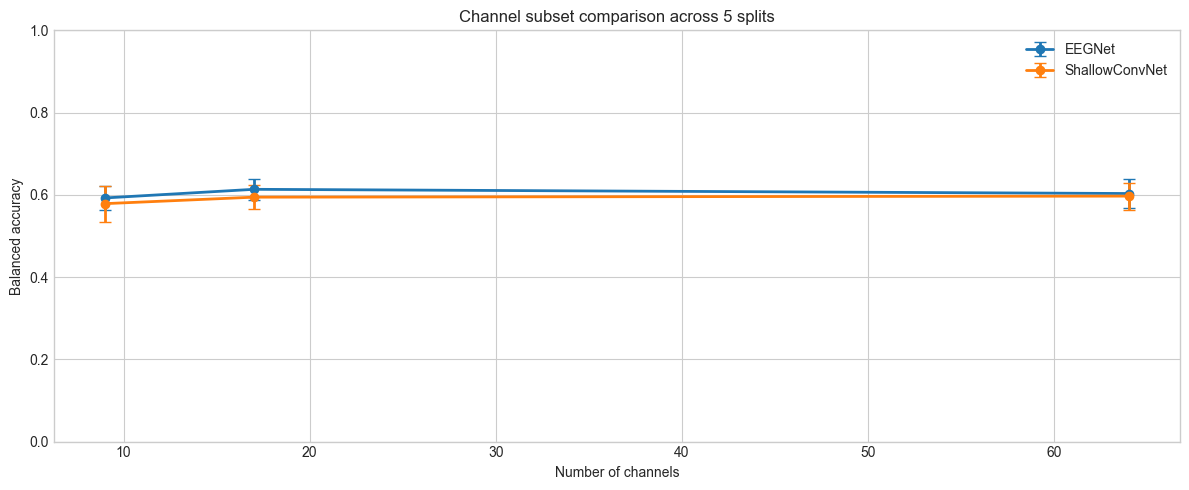

In [5]:
baseline_rows = []
for subset_name, subset_channels in CHANNEL_OPTIONS.items():
    X_subset, names_subset, chs_subset = select_channels(
        base_dataset["X"],
        base_dataset["channel_names"],
        base_dataset["chs_info"],
        subset_channels,
    )
    subset_dataset = dict(base_dataset)
    subset_dataset["X"] = X_subset
    subset_dataset["chs_info"] = chs_subset
    baseline_rows.append(run_experiment_grid(subset_dataset, channel_label=subset_name))

channel_results = pd.concat(baseline_rows, ignore_index=True)
channel_summary = (
    channel_results.groupby(["model", "channel_subset", "n_channels"], as_index=False)
    .agg(
        mean_balanced_accuracy=("test_balanced_accuracy", "mean"),
        std_balanced_accuracy=("test_balanced_accuracy", "std"),
    )
    .sort_values(["model", "mean_balanced_accuracy"], ascending=[True, False])
)
display(channel_summary)

fig, ax = plt.subplots(figsize=(12, 5))
for model_name, model_df in channel_summary.groupby("model"):
    model_df = model_df.sort_values("n_channels")
    ax.errorbar(
        model_df["n_channels"],
        model_df["mean_balanced_accuracy"],
        yerr=model_df["std_balanced_accuracy"].fillna(0.0),
        marker="o",
        linewidth=2,
        capsize=4,
        label=model_name,
    )
ax.set_title("Channel subset comparison across 5 splits")
ax.set_xlabel("Number of channels")
ax.set_ylabel("Balanced accuracy")
ax.set_ylim(0.0, 1.0)
ax.legend()
plt.tight_layout()
plt.show()


,model,crop_window,mean_balanced_accuracy,std_balanced_accuracy
0,EEGNet,"(0.5, 2.5)",0.625763,0.022752
1,EEGNet,"(0.5, 4.0)",0.617052,0.021658
2,EEGNet,"(1.0, 3.0)",0.583882,0.025613
3,ShallowConvNet,"(0.5, 2.5)",0.592863,0.031657
4,ShallowConvNet,"(0.5, 4.0)",0.586122,0.030765
5,ShallowConvNet,"(1.0, 3.0)",0.561671,0.017660


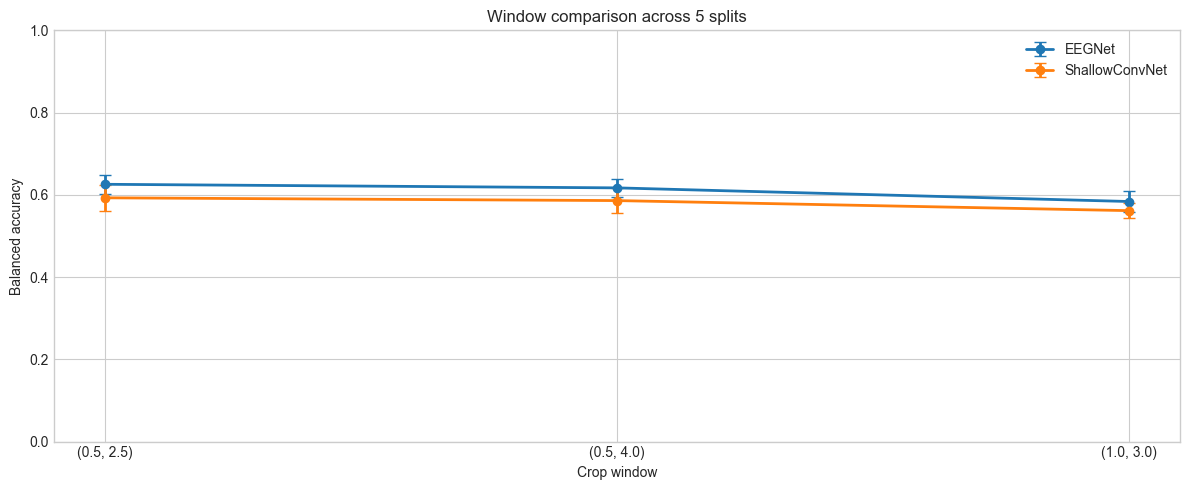

In [6]:
window_rows = []
for crop_window in WINDOW_OPTIONS:
    dataset_window = build_dataset(
        crop_window=crop_window, filter_band=DEFAULT_FILTER_BAND
    )
    window_rows.append(
        run_experiment_grid(dataset_window, channel_label="all_channels")
    )

window_results = pd.concat(window_rows, ignore_index=True)
window_summary = (
    window_results.groupby(["model", "crop_window"], as_index=False)
    .agg(
        mean_balanced_accuracy=("test_balanced_accuracy", "mean"),
        std_balanced_accuracy=("test_balanced_accuracy", "std"),
    )
    .sort_values(["model", "mean_balanced_accuracy"], ascending=[True, False])
)
display(window_summary)

fig, ax = plt.subplots(figsize=(12, 5))
for model_name, model_df in window_summary.groupby("model"):
    ax.errorbar(
        model_df["crop_window"],
        model_df["mean_balanced_accuracy"],
        yerr=model_df["std_balanced_accuracy"].fillna(0.0),
        marker="o",
        linewidth=2,
        capsize=4,
        label=model_name,
    )
ax.set_title("Window comparison across 5 splits")
ax.set_xlabel("Crop window")
ax.set_ylabel("Balanced accuracy")
ax.set_ylim(0.0, 1.0)
ax.legend()
plt.tight_layout()
plt.show()


,model,band,mean_balanced_accuracy,std_balanced_accuracy
2,EEGNet,8.0-30.0 Hz,0.617585,0.030308
1,EEGNet,8.0-14.0 Hz,0.608255,0.028064
0,EEGNet,14.0-30.0 Hz,0.597119,0.025596
5,ShallowConvNet,8.0-30.0 Hz,0.593359,0.030880
4,ShallowConvNet,8.0-14.0 Hz,0.569602,0.023993
3,ShallowConvNet,14.0-30.0 Hz,0.562885,0.014856


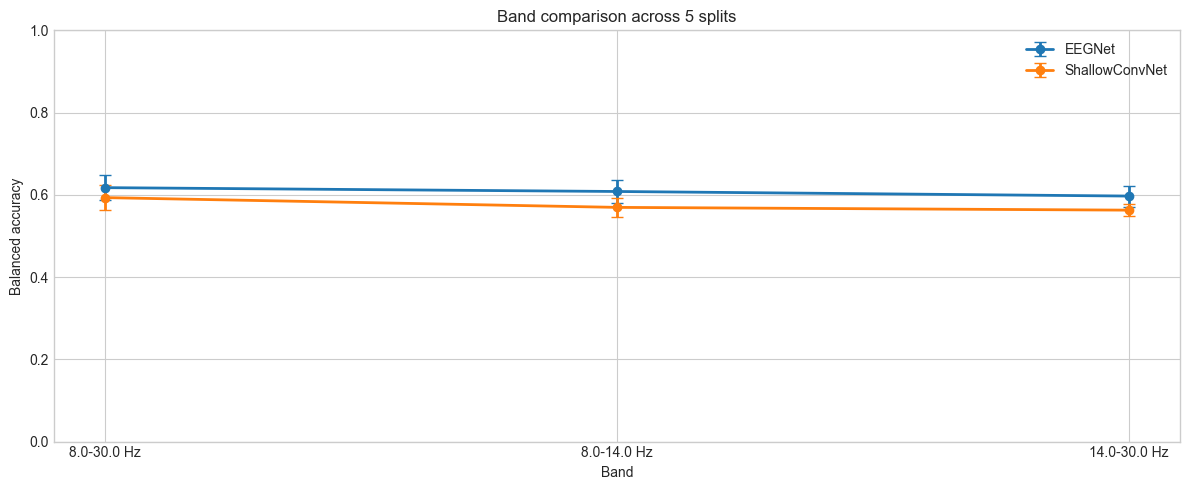

In [7]:
band_rows = []
for band in BAND_OPTIONS:
    dataset_band = build_dataset(crop_window=DEFAULT_CROP_WINDOW, filter_band=band)
    band_rows.append(run_experiment_grid(dataset_band, channel_label="all_channels"))

band_results = pd.concat(band_rows, ignore_index=True)
band_summary = (
    band_results.groupby(["model", "band"], as_index=False)
    .agg(
        mean_balanced_accuracy=("test_balanced_accuracy", "mean"),
        std_balanced_accuracy=("test_balanced_accuracy", "std"),
    )
    .sort_values(["model", "mean_balanced_accuracy"], ascending=[True, False])
)
display(band_summary)

fig, ax = plt.subplots(figsize=(12, 5))
for model_name, model_df in band_summary.groupby("model"):
    ax.errorbar(
        model_df["band"],
        model_df["mean_balanced_accuracy"],
        yerr=model_df["std_balanced_accuracy"].fillna(0.0),
        marker="o",
        linewidth=2,
        capsize=4,
        label=model_name,
    )
ax.set_title("Band comparison across 5 splits")
ax.set_xlabel("Band")
ax.set_ylabel("Balanced accuracy")
ax.set_ylim(0.0, 1.0)
ax.legend()
plt.tight_layout()
plt.show()


In [8]:
candidate_rows = []
for crop_window in WINDOW_OPTIONS:
    for band in BAND_OPTIONS:
        dataset_cfg = build_dataset(crop_window=crop_window, filter_band=band)
        for subset_name, subset_channels in CHANNEL_OPTIONS.items():
            X_subset, names_subset, chs_subset = select_channels(
                dataset_cfg["X"],
                dataset_cfg["channel_names"],
                dataset_cfg["chs_info"],
                subset_channels,
            )
            cfg_dataset = dict(dataset_cfg)
            cfg_dataset["X"] = X_subset
            cfg_dataset["chs_info"] = chs_subset
            cfg_results = run_experiment_grid(cfg_dataset, channel_label=subset_name)
            candidate_rows.append(cfg_results)

all_results = pd.concat(candidate_rows, ignore_index=True)
recommendation = (
    all_results.groupby(
        ["model", "crop_window", "band", "channel_subset", "n_channels"], as_index=False
    )
    .agg(
        mean_balanced_accuracy=("test_balanced_accuracy", "mean"),
        std_balanced_accuracy=("test_balanced_accuracy", "std"),
        mean_train_time_s=("train_time_s", "mean"),
    )
    .sort_values(
        ["mean_balanced_accuracy", "std_balanced_accuracy"], ascending=[False, True]
    )
)
display(recommendation.head(15))


KeyboardInterrupt: 